In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cv_f1_scores(models_dict, annotation_type, results_folder="./model_performance/drug_disease", save_dir="viz"):
    """
    Loads test F1 scores from 10-fold cross-validation results and plots a beeswarm chart.

    Parameters:
        models_dict (dict): Dictionary where keys are model folder names and values are short names to display.
        annotation_type (str): Annotation type to include in title and filename.
        results_folder (str): Path to the folder containing model result subfolders.
        save_dir (str): Directory where the plot image will be saved.
    """
    
    data = []

    for model_folder, shortname in models_dict.items():
        model_path = os.path.join(results_folder, model_folder)

        for i in range(10):  # 10-fold
            run_path = os.path.join(model_path, f'epochs_15_data_size_100_iter_{i}', 'test_results.json')

            if os.path.exists(run_path):
                with open(run_path, 'r') as file:
                    results = json.load(file)
                    data.append({
                        'model': shortname,
                        'run': i,
                        'test_f1': results['test_f1']
                    })
            else:
                print(f"File not found: {run_path}")

    df = pd.DataFrame(data)

    if not df.empty:
        if df.model.nunique() > 3:
            plt.figure(figsize=(12, 6))
        else:
            plt.figure(figsize=(8, 6))
        sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')

        means = df.groupby('model')['test_f1'].mean().reset_index()
        sns.scatterplot(x='model', y='test_f1', data=means, 
                        color='grey', s=150, label='Mean', marker='D', edgecolor='black')

        title = f'10-fold CV Test F1 Scores ({annotation_type})'
        plt.title(title, fontsize=16)
        plt.xlabel('Model', fontsize=16)
        plt.ylabel('Test Micro-F1 Score', fontsize=16)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.ylim(0.5, 1)
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.legend(fontsize=12, loc='lower right')

        os.makedirs(save_dir, exist_ok=True)
        filename = f"cv_10_fold_models_F1_{annotation_type}.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path)
        plt.show()
        return df
    else:
        print("No valid data found to plot.")


### DRUG and DISEASE

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_5016/2299991924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')


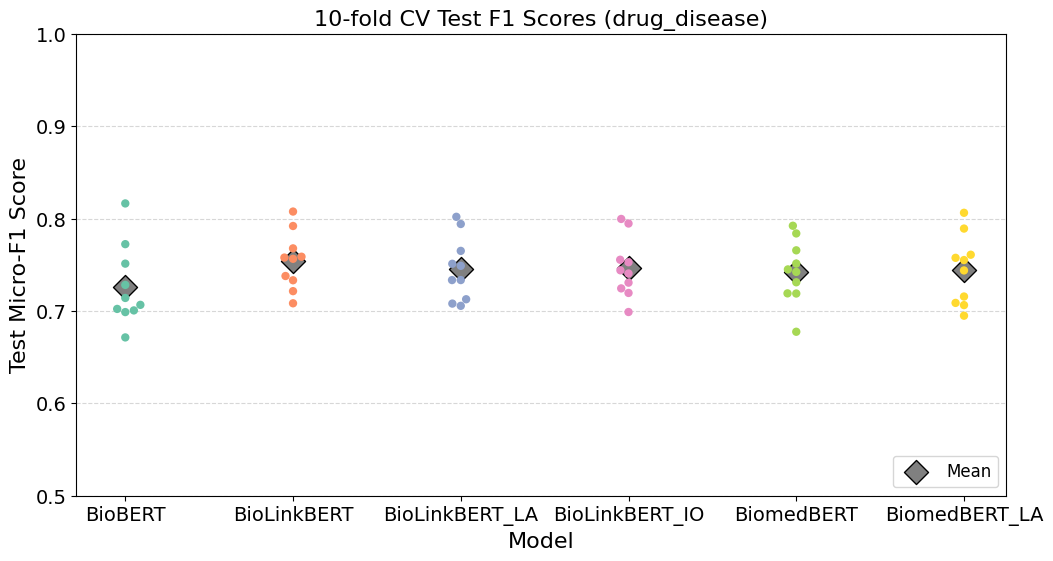

In [4]:
models = {
    'biobert-v1.1': 'BioBERT',
    'michiyasunaga_biolinkbert': 'BioLinkBERT',
    'label_all_michiyasunaga_BioLinkBERT-base': 'BioLinkBERT_LA',
    'label_all_michiyasunaga_BioLinkBERT-base-IO': 'BioLinkBERT_IO',
    'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    'label_all_microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT_LA'
}

df = plot_cv_f1_scores(models_dict=models, annotation_type="drug_disease")


In [7]:
min_performance = df.loc[df.groupby('model')['test_f1'].idxmin()].reset_index(drop=True)
max_performance = df.loc[df.groupby('model')['test_f1'].idxmax()].reset_index(drop=True)

min_performance

,model,run,test_f1
0,BioBERT,1,0.671329
1,BioLinkBERT,1,0.708261
2,BioLinkBERT_IO,1,0.698824
3,BioLinkBERT_LA,9,0.705513
4,BiomedBERT,1,0.677458
5,BiomedBERT_LA,2,0.694832


In [9]:
max_performance

,model,run,test_f1
0,BioBERT,8,0.816327
1,BioLinkBERT,8,0.807543
2,BioLinkBERT_IO,8,0.799543
3,BioLinkBERT_LA,8,0.801859
4,BiomedBERT,3,0.792173
5,BiomedBERT_LA,3,0.806206


In [11]:
median_f1 = df.groupby('model')['test_f1'].median().reset_index()

# For each model, find the run that has the test_f1 closest to the median
def find_median_run(group):
    median_value = median_f1[median_f1['model'] == group.name]['test_f1'].values[0]
    closest_idx = (group['test_f1'] - median_value).abs().idxmin()
    return group.loc[closest_idx]

# Apply the function to find the median run for each model
median_performance = df.groupby('model').apply(find_median_run).reset_index(drop=True)
median_performance

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_5016/3814185134.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_performance = df.groupby('model').apply(find_median_run).reset_index(drop=True)


,model,run,test_f1
0,BioBERT,7,0.714034
1,BioLinkBERT,4,0.757745
2,BioLinkBERT_IO,4,0.743941
3,BioLinkBERT_LA,0,0.733398
4,BiomedBERT,4,0.744935
5,BiomedBERT_LA,0,0.743812


## Strain

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_5016/2299991924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')


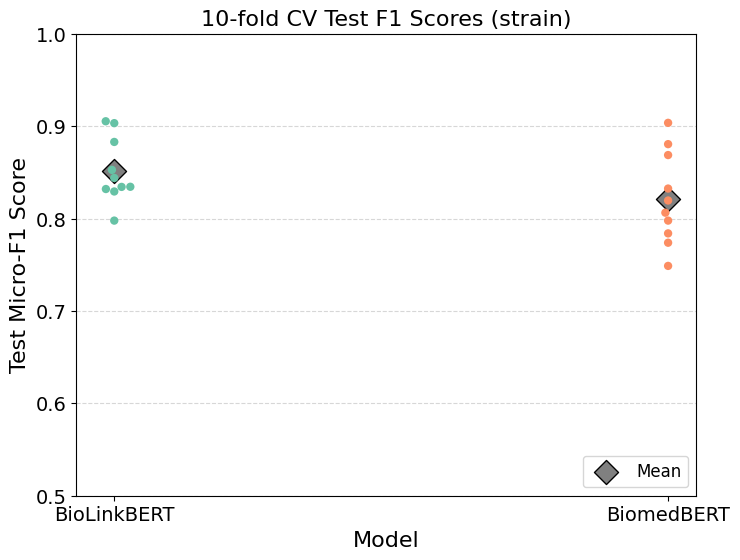

In [16]:
models = {
    'michiyasunaga_BioLinkBERT-base': 'BioLinkBERT',
    'microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract': 'BiomedBERT'
    #'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    
}

df = plot_cv_f1_scores(models_dict=models, annotation_type="strain", results_folder="./model_performance/strain")

In [18]:
df

,model,run,test_f1
0,BioLinkBERT,0,0.834356
1,BioLinkBERT,1,0.852632
2,BioLinkBERT,2,0.829268
3,BioLinkBERT,3,0.831933
4,BioLinkBERT,4,0.903226
5,BioLinkBERT,5,0.834225
6,BioLinkBERT,6,0.843931
7,BioLinkBERT,7,0.882883
8,BioLinkBERT,8,0.797753
9,BioLinkBERT,9,0.905263


# Animals nr

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_5016/2299991924.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='model', y='test_f1', data=df, size=6, palette='Set2')


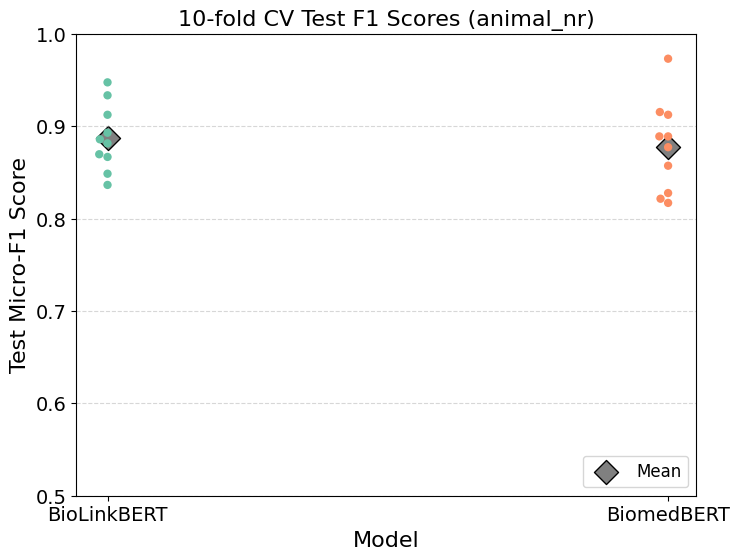

In [22]:
models = {
    'michiyasunaga_BioLinkBERT-base': 'BioLinkBERT',
    'microsoft_BiomedNLP-BiomedBERT-base-uncased-abstract': 'BiomedBERT'
    #'microsoft_BiomedBERT-base-uncased-abstract-fulltext': 'BiomedBERT',
    
}

df = plot_cv_f1_scores(models_dict=models, annotation_type="animal_nr", results_folder="./model_performance/animal_nr")